In [1]:
# main.py
import numpy as np
import os
from scipy.io import loadmat
from matplotlib import pyplot as plt

**Load and convert suite2p data**

In [2]:
from helper import suite2p2data_JSYEdit

# animal_ID = int(input("Enter animal ID (omit initials): "))
animal_ID = 26
suite_2p_data = loadmat(
    r"D:\LongitudinalImaging_Data\JSY026\RawData\NewPairing\241222_JSY_JSY026_LI_D4\TSeries-12222024-1430_Z1-001\suite2p\plane0\Fall.mat"
)
F = suite_2p_data["F"][suite_2p_data["iscell"][:, 0] == 1, :]
Fneu = suite_2p_data["Fneu"][suite_2p_data["iscell"][:, 0] == 1, :]

suite2p_processed_data = suite2p2data_JSYEdit(F, Fneu, 0, 0, 1)

file_path = 'D:\\PythonTesting\\JSY026_TestData\\'
suite2pdata_filename = 'JSY026_TestSuite2pData.npy'
suite2pdata_full_path = os.path.join(file_path, suite2pdata_filename)

# Extract the directory path
directory = os.path.dirname(suite2pdata_full_path)

# Check if the directory exists, and create it if it doesn't
if not os.path.exists(directory):
    os.makedirs(directory)
    print(f"Directory created: {directory}")

# Save the file
np.save(suite2pdata_full_path, suite2p_processed_data)
print(f"File saved: {suite2pdata_full_path}")

ModuleNotFoundError: No module named 'helper'

(152, 5084)


152

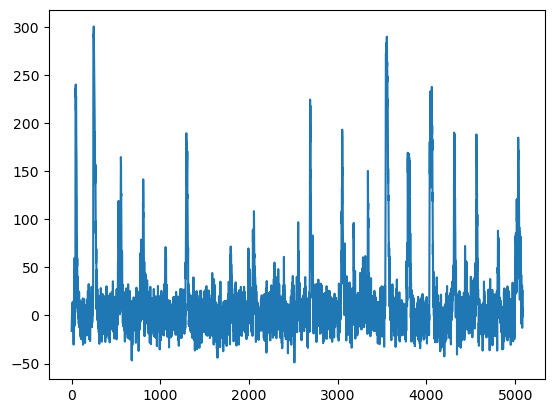

In [10]:
print(suite2p_processed_data['DFF'].shape)
plt.plot(suite2p_processed_data['DFF'][0, :])

np.size(suite2p_processed_data['DFF'], 0)

**Calculate reliability of cells**

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import numpy as np
import os
from helper import multi_naturalmovie_code_cohensd_suite2p as CorrelationCD
from scipy.io import loadmat


frameRate = 10
zplane = 1
sessionNum = 1

# Calculate reliability for each cell for each session
reliability_filenames = np.empty((zplane, sessionNum), dtype=object)
reliability_data_combined = [[None for _ in range(sessionNum)] for _ in range(zplane)]

for z_num in range(zplane):
    for session in range(sessionNum):
        cohen_thresh = 0.5
        CCprt = 90
        
        # to the existing file, file_path, add the reliability data
        file_path = "D:\\PythonTesting\\JSY026_TestData\\"
        reliability_filename = f"JSY0{{animal_ID}}__reliabilityData_{CCprt}thpercentile_{cohen_thresh}cohensthresh.npy"
        
        reliability_full_path = os.path.join(file_path, reliability_filename)
        reliability_filenames[z_num, session] = reliability_full_path

        movOn_directory = r'D:\LongitudinalImaging_Data\JSY026\RawData\NewPairing\241222_JSY_JSY026_LI_D4\TSeries-12222024-1430_Z1-001\suite2p\plane0\241222_JSY026_LI_D4_Z1_AnimalMovies_timelog.mat'
        # Check if SaveLocation exists
        if os.path.exists(file_path):
            if os.path.exists(reliability_full_path):
                print(f"{reliability_full_path} file already exists")
            else:
                print(f"Running {reliability_filename}")
                reliability_data = multi_naturalmovie_code_cohensd_suite2p(
                    suite2pdata_full_path,
                    movOn_directory,
                    frameRate,
                    cohen_thresh,
                    CCprt,
                )

                reliability_data_combined[z_num][session] = reliability_data
                # Save the reliability_data
                os.makedirs(file_path, exist_ok=True)  # Ensure directory exists
                np.save(
                    reliability_full_path, reliability_data
                )  # Save in .npy format (replace with .mat if needed)
                
def multi_naturalmovie_code_cohensd_suite2p(filename1, filename2, frame_rate, cohen_thresh, CCprt):   
    # Load data
    # check if inputs are entered
    # if not filename1:
    #     # allow the user to enter the filename
        
    #     print('Please enter a Suite2p data file')
    #     # let the user enter the directory of filename1
        
    #     return 
    suite_2p_data = np.load(filename1, allow_pickle=True)
    mov_on = loadmat(filename2)
    pres_order = loadmat(r'D:\LongitudinalImaging_Data\JSY026\2_moviepres_order.mat')
    
    print('Loading stimuli presentation order...')
    
    # Parameters
    repeats = 10
    on_time = 20
    shuffles = 1000
    num_stim = mov_on['mov_on'].shape[0]
    
    # Calculate additional parameters
    on_frames = int(round(on_time * frame_rate))
        
    # Initialize matrices
    num_cells = np.size(suite_2p_data['DFF'], 0)
    sorted_pres_order = np.zeros_like(pres_order)
    sorted_mov_on = np.zeros_like(mov_on['mov_on'])
    resp_vec = np.zeros((repeats, on_frames, num_cells, num_stim))
    
    # Sort mov_on by sorted pres_order
    for i in range(repeats):
        sorted_indices = np.argsort(pres_order[:, i])
        sorted_pres_order[:, i] = pres_order[sorted_indices, i]
        sorted_mov_on[:, i] = mov_on['mov_on'][sorted_indices, i]
    
    # Create response vector and sort DFF data
    for stim in range(num_stim):
        for rep in range(repeats):
            curr_frame = int(round(sorted_mov_on[stim, rep] * frame_rate))
            resp_vec[rep, :, :, stim] = suite_2p_data['suite2pProcessedData']['DFF'][:, curr_frame:curr_frame + on_frames].T
    
    # Test reliability of each cell
    print('Testing reliability of each cell...')
    
    iterated_CC = np.zeros((shuffles, num_cells, num_stim))
    average_CC = np.zeros((num_stim, num_cells))
    reliable_cell_vec = np.zeros((num_stim, num_cells))
    
    for stim in range(num_stim):
        for cell in range(num_cells):
            bt_CC_data = np.zeros(shuffles)
            bt_CC_rand = np.zeros(shuffles)
            
            for shuffle in range(shuffles):
                activity_data = resp_vec[:, :, cell, stim]
                activity_rand = np.array([
                    np.roll(activity_data[rep], np.random.randint(on_frames))
                    for rep in range(repeats)
                ])
                
                # Randomly split laps into two halves
                trial_shuffle = np.random.permutation(repeats)
                trial_select1 = trial_shuffle[:repeats // 2]
                trial_select2 = trial_shuffle[repeats // 2:]
                
                # Calculate CC from two halves of data
                first_half_mean = np.mean(activity_data[trial_select1], axis=0)
                second_half_mean = np.mean(activity_data[trial_select2], axis=0)
                corr_matrix = np.corrcoef(first_half_mean, second_half_mean)
                bt_CC_data[shuffle] = corr_matrix[0, 1]
                iterated_CC[shuffle, cell, stim] = corr_matrix[0, 1]
                
                # Calculate CC from two halves of randomized data
                first_half_rand_mean = np.mean(activity_rand[trial_select1], axis=0)
                second_half_rand_mean = np.mean(activity_rand[trial_select2], axis=0)
                corr_rand_matrix = np.corrcoef(first_half_rand_mean, second_half_rand_mean)
                bt_CC_rand[shuffle] = corr_rand_matrix[0, 1]
            
            average_CC[stim, cell] = np.mean(iterated_CC[:, cell, stim])
            
            # Test actual CC distribution against shuffled distribution
            avg_bt_CC_data = np.mean(bt_CC_data)
            shuff_interval = np.percentile(bt_CC_rand, CCprt)
            
            x1 = bt_CC_data
            x2 = bt_CC_rand
            n1, n2 = len(x1), len(x2)
            mean_diff = np.mean(x1) - np.mean(x2)
            pooled_sd = np.sqrt(((n1 - 1) * np.var(x1) + (n2 - 1) * np.var(x2)) / (n1 + n2 - 2))
            d = mean_diff / pooled_sd  # Cohen's d
            
            if avg_bt_CC_data > shuff_interval and d > cohen_thresh:
                reliable_cell_vec[stim, cell] = 1
    
    print(f'Total number of Responsive Cells to Stim 1 = {np.sum(reliable_cell_vec[0, :]) / num_cells * 100:.2f}%')
    print(f'Number of Responsive Cells to Stim 1 = {np.sum(reliable_cell_vec[0, :])}')
    print(f'Mean CC for Responsive Cells - Stim 1 = {np.mean(average_CC[0, reliable_cell_vec[0, :] == 1])}')
    
    print(f'Total number of Responsive Cells to Stim 2 = {np.sum(reliable_cell_vec[1, :]) / num_cells * 100:.2f}%')
    print(f'Number of Responsive Cells to Stim 2 = {np.sum(reliable_cell_vec[1, :])}')
    print(f'Mean CC for Responsive Cells - Stim 2 = {np.mean(average_CC[1, reliable_cell_vec[1, :] == 1])}')
    
    return {
        'RespVec': resp_vec,
        'reliable_cell_vec': reliable_cell_vec,
        'average_CC': average_CC
    }

Running JSY0{animal_ID}__reliabilityData_90thpercentile_0.5cohensthresh.npy


NameError: name 'multi_naturalmovie_code_cohensd_suite2p' is not defined

**Analyze behavior data**

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# File path to VRlog.txt file
VR_log_file_path = r'D:\V1_SpatialModulation\V1_SpatialMod_VRLog'
VR_log_filename = 'VRlog_JSY038_01282025_02-14-34.txt'
VR_log_full_path = os.path.join(VR_log_file_path, VR_log_filename)
# print(VR_log_full_path)

# Extract animal ID and date from the VR_log_filename
match = re.match(r'VRlog_(JSY\d+)_(\d{8})_\d{2}-\d{2}-\d{2}\.txt', VR_log_filename)
if match:
    animal_id = match.group(1)
    date = match.group(2)
else:
    print("Filename format does not match the expected pattern.")
    
# List to store raw data starting from the fourth line
rawVR_data = []

# Open the file and process it
with open(VR_log_full_path, 'r') as file:
    # Read all lines
    lines = file.readlines()
    
    # Start from the fourth line (index 3)
    for line in lines[3:]:
        # Split the line into columns (tab-separated)
        rawVR_data.append(line.strip().split('\t'))

# Extract time and location for event type 'p'
elapsed_time = []
elapsed_location = []

for entry in rawVR_data:
    if len(entry) >= 3 and entry[2] == 'p':  # Ensure the row has enough columns and the second column is 'p'
        try:
            elapsed_time.append(float(entry[1]))  # Convert elapsed time to float
            elapsed_location.append(float(entry[3]))  # Convert location to float
        except ValueError:
            # Skip rows where conversion fails
            continue
        
# calculate the number of laps (number of "n" event in the third column of rawVR_data)
num_laps = sum([1 for entry in rawVR_data if len(entry) >= 3 and entry[2] == 'n'])

0.07991201135909838


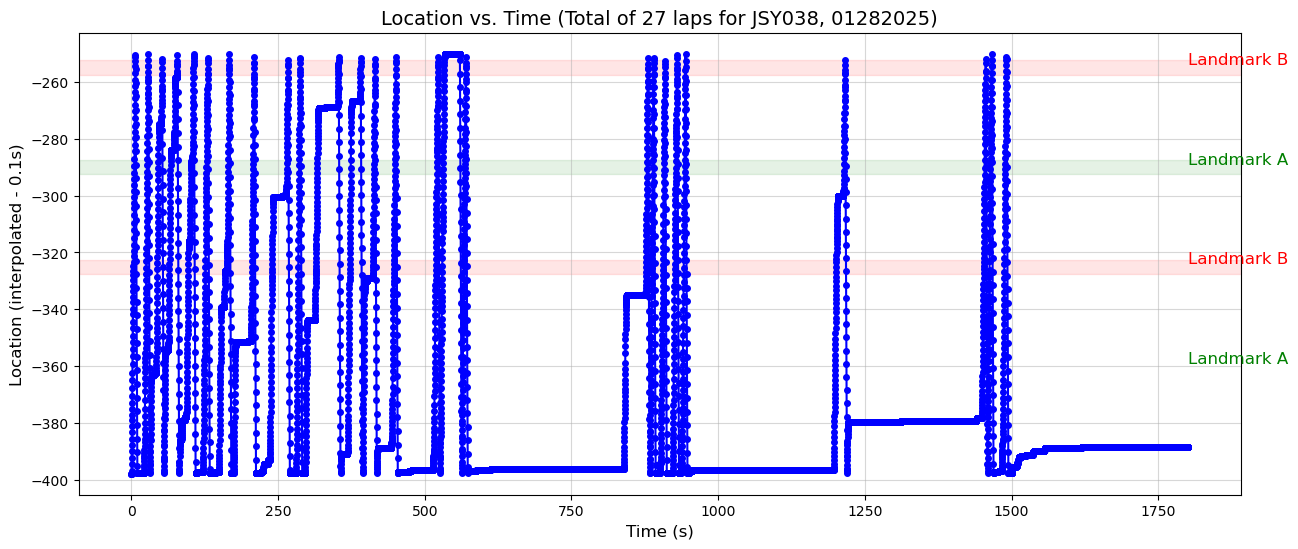

In [9]:
# calculate the average increment of time -- framerate of VR log
time_increment = np.diff(elapsed_time)
average_increment = np.mean(time_increment)
print(average_increment)

# interpolate the location data for every 0.1 s -- to match the framerate of 2p data
time_interp = np.arange(elapsed_time[0], elapsed_time[-1], 0.1)
location_interp = np.interp(time_interp, elapsed_time, elapsed_location)

# Plot location vs. time
plt.figure(figsize=(15, 6))
plt.plot(time_interp, location_interp, marker='o', linestyle='-', color='b', markersize=4)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Location (interpolated - 0.1s)', fontsize=12)
plt.title(f'Location vs. Time (Total of {num_laps} laps for {animal_id}, {date})', fontsize=14)
plt.axhspan(-292.5, -287.5, color='green', alpha=0.1)
plt.text(time_interp[-1], -360, 'Landmark A', color='green', fontsize=12, verticalalignment='bottom', horizontalalignment='left')
plt.text(time_interp[-1], -290, 'Landmark A', color='green', fontsize=12, verticalalignment='bottom', horizontalalignment='left')

plt.axhspan(-327.5, -322.5, color='red', alpha=0.1)
plt.axhspan(-257.5, -252.5, color='red', alpha=0.1)
plt.text(time_interp[-1], -325, 'Landmark B', color='red', fontsize=12, verticalalignment='bottom', horizontalalignment='left')
plt.text(time_interp[-1], -255, 'Landmark B', color='red', fontsize=12, verticalalignment='bottom', horizontalalignment='left')

plt.grid(alpha=0.5)
plt.show()

plt.show()


**Measure true distance travelled in treadmill**

In [236]:
import numpy as np
import matplotlib.pyplot as plt
import os

# File path to VRlog.txt file
log_file_path = r'D:\V1_SpatialModulation\V1_SpatialMod_VRLog'
VR_log_filename = 'VRlog_JSY038_01282025_03-39-05.txt'
VR_log_full_path = os.path.join(log_file_path, VR_log_filename)
TM_log_filename = 'TMlog_JSY038_01282025_03-39-05.txt'
TM_log_full_path = os.path.join(log_file_path, TM_log_filename)

# List to store raw data starting from the fourth line
rawVR_data = []
rawTM_data = []

# Open and process the VR log file
with open(VR_log_full_path, 'r') as file:
    rawVR_data = [line.strip().split('\t') for line in file.readlines()[3:]]

# Open and process the TM log file
with open(TM_log_full_path, 'r') as file:
    rawTM_data = [line.strip().split('\t') for line in file.readlines()[2:]]
    # Extract time, distance, and speed from VR data
    vr_time = []
    vr_event = []
    vr_distance = []

    # Extract columns from rawVR_data
    vr_time = [entry[0] for entry in rawVR_data if len(entry) >= 4]
    vr_event = [entry[2] for entry in rawVR_data if len(entry) >= 4]
    vr_distance = [float(entry[3]) for entry in rawVR_data if len(entry) >= 4]

    # Extract time, distance, and speed from treadmill data
    tm_time = []
    tm_distance = []
    tm_speed = []

    # Extract columns from rawTM_data
    tm_time = [entry[0] for entry in rawTM_data if len(entry) >= 2]
    tm_distance = [float(entry[1]) for entry in rawTM_data if len(entry) >= 2 and entry[1].replace('.', '', 1).isdigit()]
    tm_speed = [float(entry[2]) for entry in rawTM_data if len(entry) >= 3 and entry[2].replace('.', '', 1).isdigit()]

    # find indices of 'n' in vr_event
    vr_n_indices = [i for i, event in enumerate(vr_event) if event == 'n']

    # Find the first and second "n" in vr_event
    first_n = vr_n_indices[0]
    second_n = vr_n_indices[1]

    # Find the corresponding times in vr_time
    first_n_time = vr_time[first_n]
    second_n_time = vr_time[second_n]

    # Convert tm_time to seconds for comparison
    tm_time_seconds = []
    for t in tm_time:
        h, m, s_ms = t.split('.', 2)
        s, ms = s_ms.split('.')
        total_seconds = int(h) * 3600 + int(m) * 60 + int(s) + int(ms) / 1e6
        tm_time_seconds.append(total_seconds)

    # Convert first_n_time and second_n_time to seconds
    h, m, s_ms = first_n_time.split('.', 2)
    s, ms = s_ms.split('.')
    first_n_seconds = int(h) * 3600 + int(m) * 60 + int(s) + int(ms) / 1e6

    h, m, s_ms = second_n_time.split('.', 2)
    s, ms = s_ms.split('.')
    second_n_seconds = int(h) * 3600 + int(m) * 60 + int(s) + int(ms) / 1e6

    # Find the tm_distance during the time period between first_n_seconds and second_n_seconds
    distance_during_period = [dist for time, dist in zip(tm_time_seconds, tm_distance) if first_n_seconds <= time <= second_n_seconds]

    # Define max_distance as the maximum distance during this period
    max_distance = max(distance_during_period)

    # Calculate total_distance as max_distance minus the distance at the first "n" event
    total_distance = max_distance - tm_distance[first_n]

    print(f"Max distance during the period: {max_distance}")
    print(f"Total distance during the period: {total_distance}")
    print(second_n)
    print(tm_distance[second_n] - tm_distance[first_n])

Max distance during the period: 36989.15
Total distance during the period: 1814.5299999999988
163
66.44999999999709


In [ ]:
02.09.23.530897 0.3533334	p	-397.8


In [ ]:
# Check if tm_distance is empty
if not tm_distance:
    print("Error: No distance data found in the treadmill log file.")
else:
    # Calculate the number of revolutions to complete 1 trial
    # Find the maximum distance in each trial
    max_distance = max(tm_distance)

    # Calculate the number of revolutions
    revolutions = max_distance / 285.5975

    # Calculate the real-life distance in centimeters
    real_life_distance = revolutions * 27.8

    print(f"Number of revolutions to complete 1 trial: {revolutions}")
    print(f"Real-life distance in centimeters: {real_life_distance}")
    
    # Convert tm_time to seconds for plotting
    tm_time_seconds = []
    for t in tm_time:
        h, m, s_ms = t.split('.',2)
        s, ms = s_ms.split('.')
        total_seconds = int(h) * 3600 + int(m) * 60 + int(s) + int(ms) / 1e6  # Corrected conversion of microseconds
        tm_time_seconds.append(total_seconds)

    # Plot distance over time
    plt.figure(figsize=(15, 6))
    plt.plot(tm_time_seconds, tm_distance, label='Distance', color='b')
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Distance (cm)', fontsize=12)
    plt.title('Treadmill Distance Over Time', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.5)
    plt.show()

    # Plot speed over time
    plt.figure(figsize=(15, 6))
    plt.plot(tm_time_seconds, tm_speed, label='Speed', color='r')
    plt.xlabel('Time (s)', fontsize=12)
    plt.ylabel('Speed (cm/s)', fontsize=12)
    plt.title('Treadmill Speed Over Time', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.5)
    plt.show()


2230.35
